# Project 4 — MovieLens Recommender Systems

This notebook reuses the Project 3 structure, but swaps the Yelp data for MovieLens:

- `movies.csv`
- `ratings.csv`
- `links.csv`

In [178]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset, Reader, KNNBasic, SVD, accuracy
from surprise.model_selection import cross_validate, KFold, train_test_split, GridSearchCV, train_test_split

pd.set_option('display.float_format', '{:,.4f}'.format)


Another big dataset, so I had to run locally to create samples. I found that 1000 movies was manageable, but I realize the results will be messy. Below is the script that I ran to do perform the filtering. 

```python
# Folder containing movies.csv, ratings.csv, and links.csv
DATA_DIR = Path(r"C:\Users\ganzs\Documents\CUNY_Assignments\612\Project_4")

csv_files = {
    "movies": DATA_DIR / "movies.csv",
    "ratings": DATA_DIR / "ratings.csv",
    "links": DATA_DIR / "links.csv",
}

# Convert CSV files to Parquet if needed
for name, csv_path in csv_files.items():
    parquet_path = DATA_DIR / f"{name}.parquet"

    if not parquet_path.exists():
        if not csv_path.exists():
            raise FileNotFoundError(f"Missing file: {csv_path}")

        df = pd.read_csv(csv_path)
        df.to_parquet(parquet_path, index=False)
        print(f"Saved {parquet_path}")
    else:
        print(f"Already exists: {parquet_path}")

# Load MovieLens data
movies = pd.read_parquet(DATA_DIR / "movies.parquet")
ratings = pd.read_parquet(DATA_DIR / "ratings.parquet")
links = pd.read_parquet(DATA_DIR / "links.parquet")

# Keep IDs consistent
movies["movieId"] = movies["movieId"].astype(int)
ratings["movieId"] = ratings["movieId"].astype(int)
ratings["userId"] = ratings["userId"].astype(int)

movies.head(), ratings.head(), links.head()

# Load the original files
movies = pd.read_parquet(DATA_DIR / "movies_sample.parquet")
ratings = pd.read_parquet(DATA_DIR / "ratings_sample.parquet")
links = pd.read_parquet(DATA_DIR / "links_sample.parquet")

original_rating_count = len(ratings)
original_user_count = ratings["userId"].nunique()
original_movie_count = ratings["movieId"].nunique()

# Keep movies with the most rating history first
TOP_N_MOVIES = 1000

top_movie_ids = (
    ratings["movieId"]
    .value_counts()
    .head(TOP_N_MOVIES)
    .index
)

ratings_sample = ratings[ratings["movieId"].isin(top_movie_ids)].copy()

ratings_after_movie_filter = len(ratings_sample)

# Randomly sample rating rows from those movies
# This gets the gist without dragging 18M+ ratings around
RATING_ENTRY_SAMPLE_SIZE = 500_000

if len(ratings_sample) > RATING_ENTRY_SAMPLE_SIZE:
    ratings_sample = (
        ratings_sample
        .groupby("rating", group_keys=False)
        .sample(
            frac=RATING_ENTRY_SAMPLE_SIZE / len(ratings_sample),
            random_state=42
        )
        .copy()
    )

# Cull users who barely exist after the row sample
MIN_USER_RATINGS_AFTER_SAMPLE = 3

user_counts = ratings_sample["userId"].value_counts()
valid_user_ids = user_counts[user_counts >= MIN_USER_RATINGS_AFTER_SAMPLE].index

ratings_sample = ratings_sample[
    ratings_sample["userId"].isin(valid_user_ids)
].copy()

# Optional movie cleanup after user culling
# Set this to 1 if you only want to remove movies that fully disappeared
MIN_MOVIE_RATINGS_AFTER_SAMPLE = 20

movie_counts = ratings_sample["movieId"].value_counts()
valid_movie_ids = movie_counts[movie_counts >= MIN_MOVIE_RATINGS_AFTER_SAMPLE].index

ratings_sample = ratings_sample[
    ratings_sample["movieId"].isin(valid_movie_ids)
].copy()

# Keep metadata lined up with whatever survived
valid_movie_ids = ratings_sample["movieId"].unique()

movies_sample = movies[movies["movieId"].isin(valid_movie_ids)].copy()
links_sample = links[links["movieId"].isin(valid_movie_ids)].copy()

# Keep the files neat
ratings_sample = ratings_sample.sort_values(["userId", "movieId"]).reset_index(drop=True)
movies_sample = movies_sample.sort_values("movieId").reset_index(drop=True)
links_sample = links_sample.sort_values("movieId").reset_index(drop=True)

# Save the sampled version without touching the originals
movies_sample.to_parquet(DATA_DIR / "movies_sample.parquet", index=False)
ratings_sample.to_parquet(DATA_DIR / "ratings_sample.parquet", index=False)
links_sample.to_parquet(DATA_DIR / "links_sample.parquet", index=False)
```

In [179]:
# Load sampled MovieLens data from GitHub
movies_sample = pd.read_parquet(
    "https://github.com/Siganz/CUNY_Assignments/raw/refs/heads/main/612/Project_4/movies_sample.parquet"
)

ratings_sample = pd.read_parquet(
    "https://github.com/Siganz/CUNY_Assignments/raw/refs/heads/main/612/Project_4/ratings_sample.parquet"
)

links_sample = pd.read_parquet(
    "https://github.com/Siganz/CUNY_Assignments/raw/refs/heads/main/612/Project_4/links_sample.parquet"
)

# Reuse the normal names so the rest of the notebook does not need edits
movies = movies_sample.copy()
ratings = ratings_sample.copy()
links = links_sample.copy()

# Keep IDs consistent
movies["movieId"] = movies["movieId"].astype(int)
ratings["movieId"] = ratings["movieId"].astype(int)
ratings["userId"] = ratings["userId"].astype(int)
links["movieId"] = links["movieId"].astype(int)

# Original full-data metrics from the preprocessing step
original_user_count = 200948
original_movie_count = 84432
original_rating_count = 32000204
ratings_after_movie_filter = 18878392
TOP_N_MOVIES = 1000

print("Original users:", original_user_count)
print("Sample users:", ratings["userId"].nunique())

print("\nOriginal movies:", original_movie_count)
print("Top movies requested:", TOP_N_MOVIES)
print("Sample movies:", ratings["movieId"].nunique())

print("\nOriginal ratings:", original_rating_count)
print("Ratings after top movie filter:", ratings_after_movie_filter)
print("Sample ratings:", len(ratings))
print("Ratings kept from full data (%):", round(len(ratings) / original_rating_count * 100, 2))
print("Ratings kept from top movie data (%):", round(len(ratings) / ratings_after_movie_filter * 100, 2))

print("\nApprox item-item cells:", ratings["movieId"].nunique() ** 2)

assert set(ratings["movieId"]).issubset(set(movies["movieId"]))
assert set(ratings["movieId"]).issubset(set(links["movieId"]))

print("\nSample files loaded from GitHub. Variables now point to the sampled data.")

Original users: 200948
Sample users: 65985

Original movies: 84432
Top movies requested: 1000
Sample movies: 1000

Original ratings: 32000204
Ratings after top movie filter: 18878392
Sample ratings: 388698
Ratings kept from full data (%): 1.21
Ratings kept from top movie data (%): 2.06

Approx item-item cells: 1000000

Sample files loaded from GitHub. Variables now point to the sampled data.


## Base Metrics

In [180]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)

possible_ratings = n_users * n_movies
density = n_ratings / possible_ratings
sparsity = 1 - density

summary_df = pd.DataFrame({
    "Metric": [
        "Unique users",
        "Unique rated movies",
        "Total ratings",
        "Possible user-movie ratings",
        "Rating density (%)",
        "Rating sparsity (%)"
    ],
    "Value": [
        n_users,
        n_movies,
        n_ratings,
        possible_ratings,
        density * 100,
        sparsity * 100
    ]
})

summary_df["Value"] = summary_df["Value"].round(2)
print(summary_df)

                        Metric           Value
0                 Unique users     65,985.0000
1          Unique rated movies      1,000.0000
2                Total ratings    388,698.0000
3  Possible user-movie ratings 65,985,000.0000
4           Rating density (%)          0.5900
5          Rating sparsity (%)         99.4100


,rating,rating_count
0,0.5000,4719
1,1.0000,8358
2,1.5000,5302
3,2.0000,20448
4,2.5000,18403
5,3.0000,67675
6,3.5000,53709
7,4.0000,108007
8,4.5000,41494
9,5.0000,60583


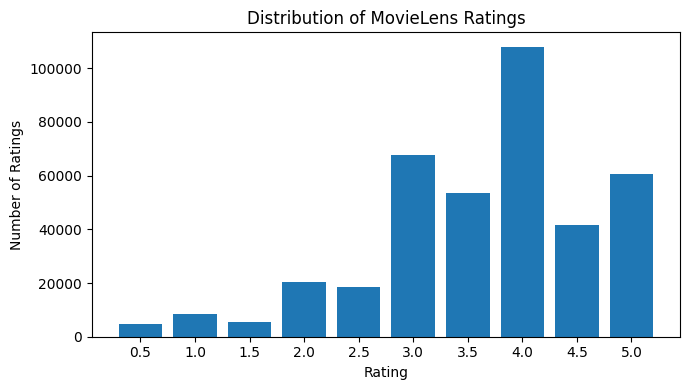

In [181]:
# Rating Distribution
rating_counts = ratings["rating"].value_counts().sort_index()

display(
    rating_counts.rename("rating_count")
    .reset_index()
    .rename(columns={"index": "rating"})
)

plt.figure(figsize=(7, 4))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Distribution of MovieLens Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

count   65,985.0000
mean         5.8907
std          3.6323
min          3.0000
25%          3.0000
50%          5.0000
75%          7.0000
max         35.0000
dtype: float64

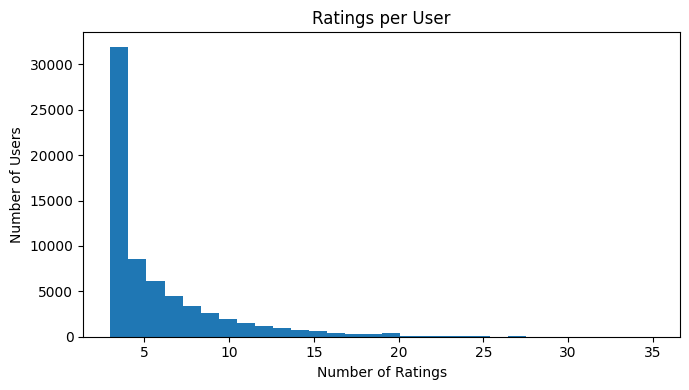

In [182]:
# Ratings per User
ratings_per_user = ratings.groupby("userId").size()

display(ratings_per_user.describe())

plt.figure(figsize=(7, 4))
plt.hist(ratings_per_user, bins=30)
plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

count   1,000.0000
mean      388.6980
std       248.1225
min       122.0000
25%       222.0000
50%       305.0000
75%       464.0000
max     1,661.0000
dtype: float64

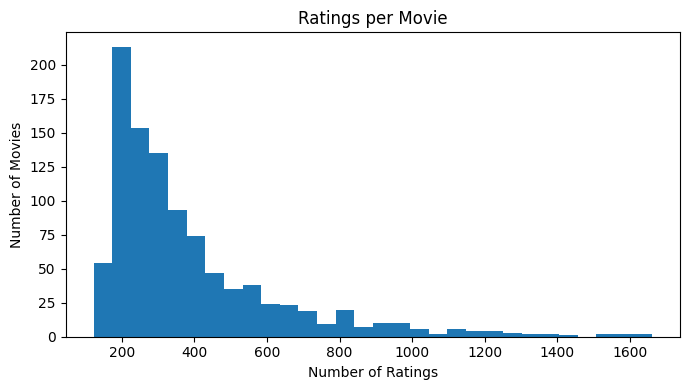

In [183]:
# Ratings per Movie
ratings_per_movie = ratings.groupby("movieId").size()

display(ratings_per_movie.describe())

plt.figure(figsize=(7, 4))
plt.hist(ratings_per_movie, bins=30)
plt.title("Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

,title,genres,rating_count,average_rating
100,Forrest Gump (1994),Comedy|Drama|Romance|War,1661,4.0629
81,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,1636,4.2353
87,"Shawshank Redemption, The (1994)",Crime|Drama,1608,4.3896
473,"Matrix, The (1999)",Action|Sci-Fi|Thriller,1588,4.1291
71,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,1529,4.0834
153,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,1525,4.1548
126,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,1407,3.6180
523,Fight Club (1999),Action|Crime|Drama|Thriller,1367,4.2308
651,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,1356,4.0302
243,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,1351,4.1577


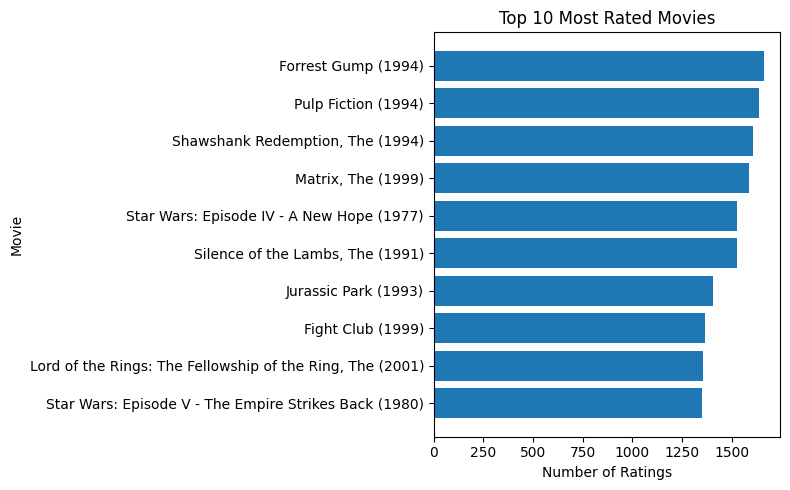

In [184]:
# Most Rated Movies
movie_rating_summary = (
    ratings.groupby("movieId")
    .agg(
        rating_count=("rating", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
    .merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")
)

top_rated_count = movie_rating_summary.sort_values(
    "rating_count",
    ascending=False
).head(10)

display(top_rated_count[["title", "genres", "rating_count", "average_rating"]])

plt.figure(figsize=(8, 5))
plt.barh(top_rated_count["title"][::-1], top_rated_count["rating_count"][::-1])
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()

## Prepare Data for Surprise

In [185]:
# Start from the current sampled ratings
surprise_ratings = ratings[["userId", "movieId", "rating"]].copy()

reader = Reader(rating_scale=(0.5, 5))
data_full = Dataset.load_from_df(surprise_ratings, reader)

# Split sampled data into 80% train and 20% hidden test
trainset_k, testset_k = train_test_split(
    data_full,
    test_size=0.20,
    random_state=42
)

# Convert hidden Surprise testset into a pandas DataFrame
ratings_k = pd.DataFrame(
    testset_k,
    columns=["userId", "movieId", "rating"]
)

# Convert Surprise trainset back into a pandas DataFrame
ratings_train = pd.DataFrame([
    {
        "userId": trainset_k.to_raw_uid(inner_uid),
        "movieId": trainset_k.to_raw_iid(inner_iid),
        "rating": rating
    }
    for inner_uid, inner_iid, rating in trainset_k.all_ratings()
])

# From this point forward, train models only on the 80% training ratings
ratings = ratings_train.copy()

# Rebuild Surprise dataset from training ratings only
surprise_ratings = ratings[["userId", "movieId", "rating"]].copy()

data = Dataset.load_from_df(surprise_ratings, reader)

trainset = data.build_full_trainset()

print("Surprise dataset created successfully.")
print(
    f"Users: {trainset.n_users}, "
    f"Movies: {trainset.n_items}, "
    f"Ratings: {trainset.n_ratings}"
)

print("\nHidden K-test set created.")
print("K-test ratings:", len(ratings_k))
print("K-test users:", ratings_k["userId"].nunique())
print("K-test movies:", ratings_k["movieId"].nunique())

Surprise dataset created successfully.
Users: 65813, Movies: 1000, Ratings: 310958

Hidden K-test set created.
K-test ratings: 77740
K-test users: 44028
K-test movies: 1000


In [186]:
def get_candidate_scores(model, user_id, movies, ratings, candidate_pool=100, skip_impossible=False):
    """
    Score unseen movies for a user using a trained Surprise model.
    Optionally skips impossible predictions for KNN models.
    """
    rated_movie_ids = set(
        ratings.loc[ratings["userId"] == user_id, "movieId"]
    )

    valid_movie_ids = set(ratings["movieId"].unique())

    candidates = movies[
        (~movies["movieId"].isin(rated_movie_ids)) &
        (movies["movieId"].isin(valid_movie_ids))
    ].copy()

    predictions = []

    for movie_id in candidates["movieId"]:
        pred = model.predict(user_id, movie_id)

        if skip_impossible and pred.details.get("was_impossible", False):
            continue

        prediction_row = {
            "movieId": movie_id,
            "predicted_rating": pred.est
        }

        if "actual_k" in pred.details:
            prediction_row["actual_k"] = pred.details["actual_k"]

        predictions.append(prediction_row)

    if len(predictions) == 0:
        return pd.DataFrame(
            columns=["movieId", "title", "genres", "predicted_rating", "actual_k"]
        )

    scored = pd.DataFrame(predictions, columns=["movieId", "predicted_rating"])

    if scored.empty:
        return pd.DataFrame(columns=["movieId", "title", "genres", "predicted_rating"])
    
    return (
        scored
        .merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")
        .sort_values("predicted_rating", ascending=False)
        .head(candidate_pool)
    )

## Recommender 1 — Item-Item Collaborative Filtering

In [187]:
def evaluate_item_item_knn(data, min_support_values=[5], cv=3, similarity_name="cosine"):
    results = []
    kfold = KFold(n_splits=cv, random_state=42, shuffle=True)

    for min_support in min_support_values:
        sim_options = {
            "name": similarity_name,
            "user_based": False,
            "min_support": min_support
        }

        algo = KNNBasic(
            k=20,
            min_k=1,
            sim_options=sim_options,
            verbose=False
        )

        print(f"\nTesting item-item KNN: similarity={similarity_name}, k=20, min_support={min_support}, cv={cv}")

        cv_results = cross_validate(
            algo,
            data,
            measures=["RMSE", "MAE"],
            cv=kfold,
            verbose=True
        )

        results.append({
            "Model": "Item-item KNN",
            "similarity": similarity_name,
            "k": 20,
            "min_support": min_support,
            "RMSE_mean": np.mean(cv_results["test_rmse"]),
            "RMSE_std": np.std(cv_results["test_rmse"]),
            "MAE_mean": np.mean(cv_results["test_mae"]),
            "MAE_std": np.std(cv_results["test_mae"]),
            "fit_time_mean": np.mean(cv_results["fit_time"]),
            "test_time_mean": np.mean(cv_results["test_time"])
        })

    return pd.DataFrame(results).sort_values("RMSE_mean")


min_support_values = [1, 3, 5, 10, 20]

item_item_results_df = evaluate_item_item_knn(
    data=data,
    min_support_values=min_support_values,
    cv=3,
    similarity_name="cosine"
)

display(item_item_results_df)


Testing item-item KNN: similarity=cosine, k=20, min_support=1, cv=3
Evaluating RMSE, MAE of algorithm KNNBasic on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    1.0950  1.1006  1.1028  1.0995  0.0033  
MAE (testset)     0.8230  0.8261  0.8297  0.8263  0.0027  
Fit time          0.09    0.14    0.15    0.13    0.02    
Test time         0.40    0.41    0.60    0.47    0.09    

Testing item-item KNN: similarity=cosine, k=20, min_support=3, cv=3
Evaluating RMSE, MAE of algorithm KNNBasic on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    1.0823  1.0865  1.0858  1.0849  0.0019  
MAE (testset)     0.8253  0.8278  0.8289  0.8273  0.0015  
Fit time          0.10    0.13    0.13    0.12    0.02    
Test time         0.40    0.39    0.58    0.46    0.09    

Testing item-item KNN: similarity=cosine, k=20, min_support=5, cv=3
Evaluating RMSE, MAE of algorithm KNNBasic on 3 split(s).

                  Fold 1  

,Model,similarity,k,min_support,RMSE_mean,RMSE_std,MAE_mean,MAE_std,fit_time_mean,test_time_mean
4,Item-item KNN,cosine,20,20,1.0051,0.0007,0.7976,0.0011,0.1196,0.4165
3,Item-item KNN,cosine,20,10,1.0062,0.0003,0.7971,0.0010,0.1267,0.4528
2,Item-item KNN,cosine,20,5,1.0350,0.0012,0.8059,0.0013,0.1216,0.4493
1,Item-item KNN,cosine,20,3,1.0849,0.0019,0.8273,0.0015,0.1221,0.4569
0,Item-item KNN,cosine,20,1,1.0995,0.0033,0.8263,0.0027,0.1262,0.4678


In [188]:
best_min_support = int(item_item_results_df.iloc[0]["min_support"])

final_item_item = KNNBasic(
    sim_options={
        "name": "cosine",
        "user_based": False,
        "min_support": best_min_support
    },
    verbose=False
)

final_item_item.fit(trainset)

print(f"Best min_support: {best_min_support}")

Best min_support: 20


In [189]:
def get_item_item_recommendations(user_id, top_n=10):
    return get_candidate_scores(
        final_item_item,
        user_id,
        movies,
        ratings,
        candidate_pool=top_n,
        skip_impossible=True
    )

In [190]:
example_user_positions = [1, 5, 489]

unique_users = ratings["userId"].drop_duplicates().reset_index(drop=True)

for pos in example_user_positions:
    example_user = unique_users.iloc[pos]
    rating_count = ratings[ratings["userId"] == example_user].shape[0]

    print(f"User from unique_users.iloc[{pos}]: {example_user}")
    print(f"Ratings by user: {rating_count}")

    display(get_item_item_recommendations(example_user, top_n=10))
    print("-" * 80)

User from unique_users.iloc[1]: 16174
Ratings by user: 5


,movieId,predicted_rating,title,genres
2,595,5.0000,Beauty and the Beast (1991),Animation|Children|Fantasy|Musical|Romance|IMAX
3,1240,2.5000,"Terminator, The (1984)",Action|Sci-Fi|Thriller
4,1270,2.5000,Back to the Future (1985),Adventure|Comedy|Sci-Fi
1,356,2.5000,Forrest Gump (1994),Comedy|Drama|Romance|War
5,5952,2.5000,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy
0,110,2.5000,Braveheart (1995),Action|Drama|War


--------------------------------------------------------------------------------
User from unique_users.iloc[5]: 14195
Ratings by user: 3


,movieId,predicted_rating,title,genres
2,33794,4.0000,Batman Begins (2005),Action|Crime|IMAX
1,356,3.7530,Forrest Gump (1994),Comedy|Drama|Romance|War
0,296,3.5000,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller


--------------------------------------------------------------------------------
User from unique_users.iloc[489]: 37793
Ratings by user: 11


,movieId,predicted_rating,title,genres
4,780,5.0000,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller
10,2858,5.0000,American Beauty (1999),Drama|Romance
3,480,5.0000,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
6,1210,4.4992,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
13,5952,4.4955,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy
0,296,4.4900,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2,356,4.3352,Forrest Gump (1994),Comedy|Drama|Romance|War
1,318,4.0000,"Shawshank Redemption, The (1994)",Crime|Drama
5,1198,4.0000,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure
8,1580,4.0000,Men in Black (a.k.a. MIB) (1997),Action|Comedy|Sci-Fi


--------------------------------------------------------------------------------


### Item-Item KNN Note

The item-item model works, but it depends a lot on the user. If the user only rated a few movies, the model does not have much history to compare against, so the recommendations can be limited or kind of weird.

The `actual_k` sometimes only had `1` or `2`, meaning the model is basing the prediction on very little neighbor information.

So item-item KNN can work, but it is sensitive to sparse users. Also, the sampling step earlier in the model probably made item-item KNN less reliable than it would be on the full dataset, but it needed to be done because it was too large to work efficiently with my current set up. 

## Recommender 2 — SVD

This is the same idea as the previous SVD recommender, but trained on MovieLens ratings.

In [191]:
param_grid = {
    "n_factors": [20, 50, 100],
    "n_epochs": [20],
    "lr_all": [0.002, 0.005, 0.01],
    "reg_all": [0.02, 0.05],
    "random_state": [42]
}

svd_grid_search = GridSearchCV(
    SVD,
    param_grid,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1
)

svd_grid_search.fit(data)

print("Best RMSE:", svd_grid_search.best_score["rmse"])
print("Best params:", svd_grid_search.best_params["rmse"])

Best RMSE: 0.897459235434536
Best params: {'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.05, 'random_state': 42}


In [192]:
svd_results_df = pd.DataFrame(svd_grid_search.cv_results)

svd_results_df = svd_results_df[
    [
        "param_n_factors",
        "param_n_epochs",
        "param_lr_all",
        "param_reg_all",
        "mean_test_rmse",
        "std_test_rmse",
        "mean_test_mae",
        "std_test_mae",
        "mean_fit_time",
        "mean_test_time"
    ]
].sort_values("mean_test_rmse")

display(svd_results_df)

,param_n_factors,param_n_epochs,param_lr_all,param_reg_all,mean_test_rmse,std_test_rmse,mean_test_mae,std_test_mae,mean_fit_time,mean_test_time
5,20,20,0.0100,0.0500,0.8975,0.0014,0.6883,0.0007,0.5051,0.3949
3,20,20,0.0050,0.0500,0.8996,0.0019,0.6910,0.0010,0.4961,0.3791
2,20,20,0.0050,0.0200,0.9012,0.0018,0.6923,0.0010,0.4908,0.3619
9,50,20,0.0050,0.0500,0.9021,0.0021,0.6931,0.0011,0.7381,0.4104
11,50,20,0.0100,0.0500,0.9022,0.0020,0.6922,0.0013,0.7349,0.3844
15,100,20,0.0050,0.0500,0.9046,0.0019,0.6957,0.0008,1.1252,0.3933
17,100,20,0.0100,0.0500,0.9049,0.0018,0.6955,0.0007,1.0743,0.3409
8,50,20,0.0050,0.0200,0.9064,0.0021,0.6966,0.0012,0.7476,0.4123
4,20,20,0.0100,0.0200,0.9080,0.0011,0.6970,0.0004,0.4896,0.3732
14,100,20,0.0050,0.0200,0.9118,0.0019,0.7020,0.0007,1.1090,0.4006


In [193]:
best_svd_params = svd_grid_search.best_params["rmse"]

final_svd_algo = SVD(**best_svd_params)
final_svd_algo.fit(trainset)

print("Final SVD model trained.")
print(best_svd_params)

Final SVD model trained.
{'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.05, 'random_state': 42}


In [194]:
trainset = data.build_full_trainset()

best_svd_params = svd_grid_search.best_params["rmse"]

final_svd = SVD(**best_svd_params)
final_svd.fit(trainset)

In [195]:
def get_svd_recommendations(user_id, top_n=10):
    return get_candidate_scores(
        final_svd,
        user_id,
        movies,
        ratings,
        candidate_pool=top_n,
        skip_impossible=False
    )

In [196]:
example_user_positions = [1, 5, 489]

unique_users = ratings["userId"].drop_duplicates().reset_index(drop=True)

for pos in example_user_positions:
    example_user = unique_users.iloc[pos]
    rating_count = ratings[ratings["userId"] == example_user].shape[0]

    print(f"User from unique_users.iloc[{pos}]: {example_user}")
    print(f"Ratings by user: {rating_count}")

    display(get_svd_recommendations(example_user, top_n=10))
    print("-" * 80)

User from unique_users.iloc[1]: 16174
Ratings by user: 5


,movieId,predicted_rating,title,genres
194,908,4.7711,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller
681,5971,4.7642,My Neighbor Totoro (Tonari no Totoro) (1988),Animation|Children|Drama|Fantasy
203,924,4.7527,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi
260,1221,4.7247,"Godfather: Part II, The (1974)",Crime|Drama
522,2959,4.7150,Fight Club (1999),Action|Crime|Drama|Thriller
941,109487,4.7044,Interstellar (2014),Sci-Fi|IMAX
87,318,4.6940,"Shawshank Redemption, The (1994)",Crime|Drama
168,720,4.6861,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy
174,750,4.6838,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War
685,6016,4.6773,City of God (Cidade de Deus) (2002),Action|Adventure|Crime|Drama|Thriller


--------------------------------------------------------------------------------
User from unique_users.iloc[5]: 14195
Ratings by user: 3


,movieId,predicted_rating,title,genres
188,858,4.3989,"Godfather, The (1972)",Crime|Drama
404,2019,4.3826,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama
85,318,4.3751,"Shawshank Redemption, The (1994)",Crime|Drama
134,527,4.2996,Schindler's List (1993),Drama|War
273,1247,4.2800,"Graduate, The (1967)",Comedy|Drama|Romance
167,720,4.2668,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy
682,5971,4.2581,My Neighbor Totoro (Tonari no Totoro) (1988),Animation|Children|Drama|Fantasy
24,50,4.2502,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
247,1203,4.2499,12 Angry Men (1957),Drama
173,750,4.2398,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War


--------------------------------------------------------------------------------
User from unique_users.iloc[489]: 37793
Ratings by user: 11


,movieId,predicted_rating,title,genres
84,318,3.8374,"Shawshank Redemption, The (1994)",Crime|Drama
80,296,3.7154,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
187,858,3.7051,"Godfather, The (1972)",Crime|Drama
257,1221,3.6929,"Godfather: Part II, The (1974)",Crime|Drama
401,2019,3.6835,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama
191,904,3.6782,Rear Window (1954),Mystery|Thriller
97,356,3.6740,Forrest Gump (1994),Comedy|Drama|Romance|War
172,750,3.6739,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War
240,1197,3.6650,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance
166,720,3.6644,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy


--------------------------------------------------------------------------------


## Accuracy Comparison: Item-Item KNN vs SVD

In [197]:
def precision_recall_at_k(
    model,
    ratings_train,
    ratings_test,
    movies,
    k=10,
    relevance_threshold=4.0,
    max_users=500,
    skip_impossible=False
):
    """
    Offline Precision@K and Recall@K.
    """
    valid_movie_ids = set(ratings_train["movieId"].unique())

    test_users = (
        ratings_test.loc[ratings_test["rating"] >= relevance_threshold, "userId"]
        .drop_duplicates()
        .head(max_users)
        .tolist()
    )

    precisions = []
    recalls = []

    for user_id in test_users:
        train_seen = set(
            ratings_train.loc[ratings_train["userId"] == user_id, "movieId"]
        )

        relevant_test_items = set(
            ratings_test.loc[
                (ratings_test["userId"] == user_id) &
                (ratings_test["rating"] >= relevance_threshold),
                "movieId"
            ]
        )

        if len(relevant_test_items) == 0:
            continue

        candidate_movie_ids = [
            movie_id
            for movie_id in valid_movie_ids
            if movie_id not in train_seen
        ]

        predictions = []

        for movie_id in candidate_movie_ids:
            pred = model.predict(user_id, movie_id)

            if skip_impossible and pred.details.get("was_impossible", False):
                continue

            predictions.append((movie_id, pred.est))

        top_k_items = [
            movie_id
            for movie_id, _ in sorted(
                predictions,
                key=lambda x: x[1],
                reverse=True
            )[:k]
        ]

        hits = len(set(top_k_items) & relevant_test_items)

        precisions.append(hits / k)
        recalls.append(hits / len(relevant_test_items))

    return {
        f"Precision@{k}": np.mean(precisions),
        f"Recall@{k}": np.mean(recalls),
        "Evaluated Users": len(precisions)
    }

In [198]:
K = 10
RELEVANCE_THRESHOLD = 4.0

item_item_topn_metrics = precision_recall_at_k(
    model=final_item_item,
    ratings_train=ratings,
    ratings_test=ratings_k,
    movies=movies,
    k=K,
    relevance_threshold=RELEVANCE_THRESHOLD,
    max_users=500,
    skip_impossible=True
)

svd_topn_metrics = precision_recall_at_k(
    model=final_svd,
    ratings_train=ratings,
    ratings_test=ratings_k,
    movies=movies,
    k=K,
    relevance_threshold=RELEVANCE_THRESHOLD,
    max_users=500,
    skip_impossible=False
)

print("Item-Item KNN:", item_item_topn_metrics)
print("SVD:", svd_topn_metrics)

Item-Item KNN: {'Precision@10': np.float64(0.002), 'Recall@10': np.float64(0.013066666666666666), 'Evaluated Users': 500}
SVD: {'Precision@10': np.float64(0.0036), 'Recall@10': np.float64(0.019733333333333335), 'Evaluated Users': 500}


In [199]:
best_item_item = item_item_results_df.iloc[0]
best_svd = svd_results_df.iloc[0]

rating_model_comparison = pd.DataFrame([
    {
        "Model": "Item-Item KNN",
        "Best Parameters": (
            f"similarity={best_item_item['similarity']}, "
            f"k={int(best_item_item['k'])}, "
            f"min_support={int(best_item_item['min_support'])}"
        ),
        "RMSE_mean": best_item_item["RMSE_mean"],
        "RMSE_std": best_item_item["RMSE_std"],
        "MAE_mean": best_item_item["MAE_mean"],
        "MAE_std": best_item_item["MAE_std"],
        f"Precision@{K}": item_item_topn_metrics[f"Precision@{K}"],
        f"Recall@{K}": item_item_topn_metrics[f"Recall@{K}"],
        "Evaluated Users": item_item_topn_metrics["Evaluated Users"]
    },
    {
        "Model": "SVD",
        "Best Parameters": (
            f"n_factors={int(best_svd['param_n_factors'])}, "
            f"n_epochs={int(best_svd['param_n_epochs'])}, "
            f"lr_all={best_svd['param_lr_all']}, "
            f"reg_all={best_svd['param_reg_all']}"
        ),
        "RMSE_mean": best_svd["mean_test_rmse"],
        "RMSE_std": best_svd["std_test_rmse"],
        "MAE_mean": best_svd["mean_test_mae"],
        "MAE_std": best_svd["std_test_mae"],
        f"Precision@{K}": svd_topn_metrics[f"Precision@{K}"],
        f"Recall@{K}": svd_topn_metrics[f"Recall@{K}"],
        "Evaluated Users": svd_topn_metrics["Evaluated Users"]
    }
]).sort_values("RMSE_mean")

display(rating_model_comparison.round(4))

,Model,Best Parameters,RMSE_mean,RMSE_std,MAE_mean,MAE_std,Precision@10,Recall@10,Evaluated Users
1,SVD,"n_factors=20, n_epochs=20, lr_all=0.01, reg_al...",0.8975,0.0014,0.6883,0.0007,0.0036,0.0197,500
0,Item-Item KNN,"similarity=cosine, k=20, min_support=20",1.0051,0.0007,0.7976,0.0011,0.0020,0.0131,500


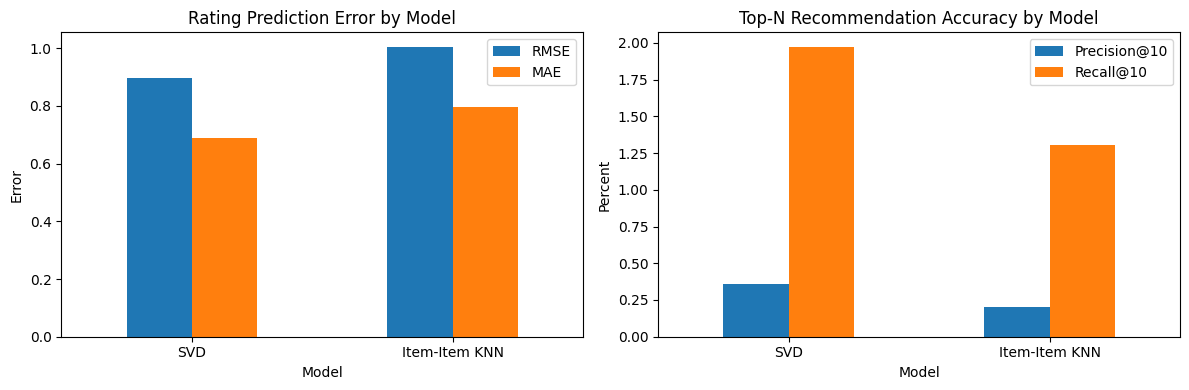

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Rating prediction error: lower is better ---
rating_model_comparison.set_index("Model")[["RMSE_mean", "MAE_mean"]].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Rating Prediction Error by Model")
axes[0].set_ylabel("Error")
axes[0].set_xlabel("Model")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["RMSE", "MAE"])


# --- Top-N recommendation metrics: higher is better ---
topn_cols = [col for col in rating_model_comparison.columns 
             if col.startswith("Precision@") or col.startswith("Recall@")]

topn_plot_df = rating_model_comparison.set_index("Model")[topn_cols] * 100

topn_plot_df.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Top-N Recommendation Accuracy by Model")
axes[1].set_ylabel("Percent")
axes[1].set_xlabel("Model")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(topn_cols)

plt.tight_layout()
plt.show()

SVD outperformed Item-Item KNN across both rating prediction and top-N recommendation metrics.

SVD had lower RMSE and MAE, meaning its predicted ratings were closer to the actual ratings. It also had higher Precision@10 and Recall@10, meaning its top-10 recommendations found slightly more relevant movies from the held-out test set.

Both models still had low Precision@10 and Recall@10. Part of that comes from the evaluation itself: users only rate a small number of movies, so a good recommendation can still be counted as wrong if it does not appear in the test set.

The low scores may also come from our earlier random sampling. We reduced the data from about 32 million ratings to about 388k ratings, keeping only 1.21% of the full dataset. That made the rating matrix much more sparse.

This hurts Item-Item KNN especially because it needs users to rate the same movies to calculate reliable movie-to-movie similarity. SVD probably could have handled more data, but Item-Item KNN on the full dataset would have taken forever. So we used the sampled data for both models to keep the comparison fair. Item-Item KNN was the main bottleneck.

## UX Goal — Diversity Reranking

The business/user-experience goal here is **increased diversity**.

The baseline SVD recommender picks the highest predicted ratings. The diversity reranker still cares about predicted rating, but it also rewards movies whose genres are different from movies already selected in the same recommendation list.

This usually increases genre diversity but may slightly lower rating accuracy. That tradeoff is the point of this section.

In [201]:
def parse_genres(genres):
    """
    Convert MovieLens genre string into a set.
    Example: "Action|Adventure|Sci-Fi" -> {"Action", "Adventure", "Sci-Fi"}
    """
    if pd.isna(genres) or genres == "(no genres listed)":
        return set()
    return set(genres.split("|"))


def genre_distance(genres_a, genres_b):
    """
    Jaccard genre distance between two movies.
    0 = same genres
    1 = no shared genres
    """
    a = parse_genres(genres_a)
    b = parse_genres(genres_b)

    if not a and not b:
        return 0

    return 1 - (len(a & b) / len(a | b))


def average_genre_diversity(recs):
    """
    Average pairwise genre distance across a recommendation list.
    Higher = more diverse.
    """
    distances = []

    for i in range(len(recs)):
        for j in range(i + 1, len(recs)):
            distances.append(
                genre_distance(
                    recs.iloc[i]["genres"],
                    recs.iloc[j]["genres"]
                )
            )

    return np.mean(distances) if distances else 0

In [202]:
def rerank_for_diversity(candidate_df, top_n=10, diversity_weight=0.25):
    """
    Greedily rerank recommendations using predicted rating + genre diversity.
    """
    candidates = candidate_df.copy()
    selected = []

    while len(selected) < top_n and not candidates.empty:
        best_idx = None
        best_score = -np.inf

        for idx, row in candidates.iterrows():
            if not selected:
                diversity_bonus = 0
            else:
                diversity_bonus = np.mean([
                    genre_distance(row["genres"], selected_row["genres"])
                    for selected_row in selected
                ])

            score = row["predicted_rating"] + diversity_weight * diversity_bonus

            if score > best_score:
                best_score = score
                best_idx = idx

        selected.append(candidates.loc[best_idx])
        candidates = candidates.drop(index=best_idx)

    return pd.DataFrame(selected)

In [203]:
MIN_DEMO_USER_RATINGS = 25
top_n = 10
candidate_pool = 1000

user_rating_counts = ratings.groupby("userId").size()
eligible_users = user_rating_counts[user_rating_counts >= MIN_DEMO_USER_RATINGS].index

selected_user = None
selected_item_candidates = None
selected_svd_candidates = None

for possible_user_id in eligible_users[:500]:
    item_candidates = get_candidate_scores(
        final_item_item,
        possible_user_id,
        movies,
        ratings,
        candidate_pool=candidate_pool,
        skip_impossible=True
    )

    if len(item_candidates) >= top_n:
        svd_candidates = get_candidate_scores(
            final_svd,
            possible_user_id,
            movies,
            ratings,
            candidate_pool=candidate_pool,
            skip_impossible=False
        )

        selected_user = possible_user_id
        selected_item_candidates = item_candidates
        selected_svd_candidates = svd_candidates
        break

user_id = selected_user
item_candidates = selected_item_candidates
svd_candidates = selected_svd_candidates

print("Selected user:", user_id)
print("Ratings by selected user:", user_rating_counts.loc[user_id])
print("Item-Item candidate count:", len(item_candidates))
print("SVD candidate count:", len(svd_candidates))

Selected user: 15875
Ratings by selected user: 28
Item-Item candidate count: 15
SVD candidate count: 972


In [204]:
item_item_base_recs = item_candidates.head(top_n)
svd_base_recs = svd_candidates.head(top_n)

item_item_diverse_recs = rerank_for_diversity(
    item_candidates,
    top_n=top_n,
    diversity_weight=0.25
)

svd_diverse_recs = rerank_for_diversity(
    svd_candidates,
    top_n=top_n,
    diversity_weight=0.25
)

In [205]:
print("Base: Item-Item KNN Recommendations")
display(item_item_base_recs[["movieId", "title", "genres", "predicted_rating"]].round(4))

print("Diversity Reranked: Item-Item KNN Recommendations")
display(item_item_diverse_recs[["movieId", "title", "genres", "predicted_rating"]].round(4))

print("-" * 80)

print("Base: SVD Recommendations")
display(svd_base_recs[["movieId", "title", "genres", "predicted_rating"]].round(4))

print("Diversity Reranked: SVD Recommendations")
display(svd_diverse_recs[["movieId", "title", "genres", "predicted_rating"]].round(4))

Base: Item-Item KNN Recommendations


,movieId,title,genres,predicted_rating
0,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.0000
1,110,Braveheart (1995),Action|Drama|War,4.0000
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.0000
3,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.0000
4,344,Ace Ventura: Pet Detective (1994),Comedy,4.0000
5,356,Forrest Gump (1994),Comedy|Drama|Romance|War,4.0000
6,364,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,4.0000
7,367,"Mask, The (1994)",Action|Comedy|Crime|Fantasy,4.0000
8,377,Speed (1994),Action|Romance|Thriller,4.0000
9,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.0000


Diversity Reranked: Item-Item KNN Recommendations


,movieId,title,genres,predicted_rating
0,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.0000
1,110,Braveheart (1995),Action|Drama|War,4.0000
4,344,Ace Ventura: Pet Detective (1994),Comedy,4.0000
14,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,4.0000
13,2858,American Beauty (1999),Drama|Romance,4.0000
6,364,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,4.0000
9,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.0000
11,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,4.0000
8,377,Speed (1994),Action|Romance|Thriller,4.0000
3,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.0000


--------------------------------------------------------------------------------
Base: SVD Recommendations


,movieId,title,genres,predicted_rating
167,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,4.1266
78,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.1178
84,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.0947
664,5971,My Neighbor Totoro (Tonari no Totoro) (1988),Animation|Children|Drama|Fantasy,4.0632
242,1207,To Kill a Mockingbird (1962),Drama,4.0364
289,1304,Butch Cassidy and the Sundance Kid (1969),Action|Western,4.0150
493,2858,American Beauty (1999),Drama|Romance,4.0097
182,858,"Godfather, The (1972)",Crime|Drama,3.9979
187,908,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller,3.9968
697,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,3.9872


Diversity Reranked: SVD Recommendations


,movieId,title,genres,predicted_rating
167,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,4.1266
84,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.0947
664,5971,My Neighbor Totoro (Tonari no Totoro) (1988),Animation|Children|Drama|Fantasy,4.0632
78,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.1178
289,1304,Butch Cassidy and the Sundance Kid (1969),Action|Western,4.0150
242,1207,To Kill a Mockingbird (1962),Drama,4.0364
187,908,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller,3.9968
493,2858,American Beauty (1999),Drama|Romance,4.0097
652,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,Adventure|Animation|Fantasy,3.9710
505,2951,"Fistful of Dollars, A (Per un pugno di dollari...",Action|Western,3.9820


In [206]:
diversity_comparison = pd.DataFrame([
    {
        "Model": "Item-Item KNN",
        "Recommendation Type": "Base",
        "Mean Predicted Rating": item_item_base_recs["predicted_rating"].mean(),
        "Genre Diversity": average_genre_diversity(item_item_base_recs)
    },
    {
        "Model": "Item-Item KNN",
        "Recommendation Type": "Diversity Reranked",
        "Mean Predicted Rating": item_item_diverse_recs["predicted_rating"].mean(),
        "Genre Diversity": average_genre_diversity(item_item_diverse_recs)
    },
    {
        "Model": "SVD",
        "Recommendation Type": "Base",
        "Mean Predicted Rating": svd_base_recs["predicted_rating"].mean(),
        "Genre Diversity": average_genre_diversity(svd_base_recs)
    },
    {
        "Model": "SVD",
        "Recommendation Type": "Diversity Reranked",
        "Mean Predicted Rating": svd_diverse_recs["predicted_rating"].mean(),
        "Genre Diversity": average_genre_diversity(svd_diverse_recs)
    }
])

display(diversity_comparison.round(4))

,Model,Recommendation Type,Mean Predicted Rating,Genre Diversity
0,Item-Item KNN,Base,4.0000,0.8407
1,Item-Item KNN,Diversity Reranked,4.0000,0.9108
2,SVD,Base,4.0445,0.8204
3,SVD,Diversity Reranked,4.0413,0.8790


The diversity ranking model, did indeed increase diversity for both Item-Item & SVD when compared to the base rankings. 

In [207]:
print("Item-Item candidate count:", len(item_candidates))
print("SVD candidate count:", len(svd_candidates))

Item-Item candidate count: 15
SVD candidate count: 972


**Interesting Note:** Item-Item KNN only gave us 15 usable candidates, so the diversity reranker barely had anything to work with. It is not really a reranking problem — Item-Item just did not produce enough options.

This probably comes from the sampled dataset being sparse. Item-Item needs shared rating overlap to score movies, and a lot of predictions were marked impossible. SVD worked better for this UX demo because it produced a much larger candidate pool.

## Offline Top-N Accuracy Before and After Diversity Reranking

RMSE and MAE evaluate rating prediction. After reranking, the model's predicted ratings do not change, but the selected recommendation list changes.

So this section compares top-N recommendation accuracy before and after reranking using:

- `Precision@K`
- `Recall@K`
- average genre diversity
- average predicted rating

A held-out test item is treated as relevant when the user rated it 4 stars or higher.

In [208]:
def precision_recall_for_recs(recs, user_id, ratings_test, k=10, relevance_threshold=4.0):
    """
    Evaluate one recommendation list for one user.
    """
    recommended_items = set(recs.head(k)["movieId"])

    relevant_items = set(
        ratings_test.loc[
            (ratings_test["userId"] == user_id) &
            (ratings_test["rating"] >= relevance_threshold),
            "movieId"
        ]
    )

    if len(relevant_items) == 0:
        return {
            f"Precision@{k}": np.nan,
            f"Recall@{k}": np.nan
        }

    hits = len(recommended_items & relevant_items)

    return {
        f"Precision@{k}": hits / k,
        f"Recall@{k}": hits / len(relevant_items)
    }


def evaluate_svd_base_vs_diversity(
    final_svd,
    ratings_train,
    ratings_test,
    movies,
    k=10,
    candidate_pool=1000,
    relevance_threshold=4.0,
    diversity_weight=0.25,
    max_users=500
):
    """
    Compare existing SVD recommendations before and after diversity reranking.
    Uses the already-trained final_svd model.
    """
    test_users = (
        ratings_test.loc[ratings_test["rating"] >= relevance_threshold, "userId"]
        .drop_duplicates()
        .head(max_users)
        .tolist()
    )

    rows = []

    for user_id in test_users:
        candidates = get_candidate_scores(
            final_svd,
            user_id,
            movies,
            ratings_train,
            candidate_pool=candidate_pool,
            skip_impossible=False
        )

        if candidates.empty:
            continue

        base_recs = candidates.head(k)

        diversity_recs = rerank_for_diversity(
            candidates,
            top_n=k,
            diversity_weight=diversity_weight
        )

        base_metrics = precision_recall_for_recs(
            base_recs,
            user_id,
            ratings_test,
            k=k,
            relevance_threshold=relevance_threshold
        )

        diversity_metrics = precision_recall_for_recs(
            diversity_recs,
            user_id,
            ratings_test,
            k=k,
            relevance_threshold=relevance_threshold
        )

        rows.append({
            "Version": "Base SVD",
            **base_metrics
        })

        rows.append({
            "Version": "Diversity Reranked SVD",
            **diversity_metrics
        })

    return (
        pd.DataFrame(rows)
        .groupby("Version", as_index=False)
        .mean()
    )

In [209]:
diversity_accuracy_comparison = evaluate_svd_base_vs_diversity(
    final_svd=final_svd,
    ratings_train=ratings,
    ratings_test=ratings_k,
    movies=movies,
    k=10,
    candidate_pool=200,
    diversity_weight=0.25,
    max_users=50
)

display(diversity_accuracy_comparison.round(4))

,Version,Precision@10,Recall@10
0,Base SVD,0.0040,0.0133
1,Diversity Reranked SVD,0.0040,0.0167


To keep runtime manageable, the before-and-after diversity comparison was evaluated on a smaller sample of users and candidate movies. The same sample and evaluation logic were used for both versions, so the comparison is still consistent.

After diversity reranking, Precision@10 stayed the same at 0.0040, while Recall@10 increased from 0.0133 to 0.0167. This means the diversity reranking step did not reduce top-10 precision and slightly improved recall.

The improvement is small and we don't know if it's due to random chance, so I would not treat it as a major accuracy gain. The main takeaway is that the diversity reranker supported the UX goal of more varied recommendations while mostly preserving recommendation accuracy.

## Online Evaluation

If online evaluation were possible, I would test metrics that show real user behavior, such as completion rate, dwell time, likes, shares, skips, and click-through rate. These would show whether users actually engage with the recommendations, instead of only measuring offline rating accuracy.

I would design an A/B test comparing the base SVD recommender against the diversity-reranked version. Users would be randomly split into a control group and a treatment group. The control group would receive the original SVD recommendations, while the treatment group would receive the diversity-reranked recommendations.

If I could extend the system further, I would use a more advanced model similar to X’s Phoenix transformer model. Instead of only using ratings, the model could learn from richer behavior signals like watch time, completion, likes, skips, and shares. These signals could be used to predict what users are likely to engage with next.

A reasonable online evaluation environment would need to serve recommendations quickly, log user events, and compare results across experiment groups. I would use a scalable system such as Spark to process large interaction data and track metrics across users. I would also use systems that can handle more data, since the data sampling created sparsity issues for these models. A larger-scale setup would make it possible to train and evaluate on more complete user-item interactions instead of relying on a heavily sampled dataset.

## Final

The main limitation of this project was the aggressive filtering needed to make the Item-Item KNN model run in a reasonable amount of time. The original dataset was much larger, but the final sample kept only a small portion of the ratings. This made the user-item matrix more sparse, which hurt Item-Item KNN because it depends heavily on shared rating overlap between movies.

SVD handled the sparse data better than Item-Item KNN and performed better across the main accuracy metrics. However, SVD likely could have benefited from using more of the original dataset. In that sense, the filtering was mostly necessary because of the computational cost of Item-Item KNN, but it also limited the performance of the overall comparison.

I wish I spent more time on this project. I could've redone the filtering to find a better balance between data and processing. It made the Item-Item KNN results bad, and the whole reason the filtering was so aggressive was because of the Item-Item KNN, so the SVD suffered as well.